In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/ATMA-V Dataset"
VIDEO_DIR = f"{BASE_DIR}/videos"
LABEL_FILE = f"{BASE_DIR}/labels/labels.txt"

print("BASE_DIR:", BASE_DIR)
print("VIDEO_DIR:", VIDEO_DIR)
print("LABEL_FILE:", LABEL_FILE)

assert os.path.exists(VIDEO_DIR), "Video directory not found!"
assert os.path.exists(LABEL_FILE), "Labels file not found!"


BASE_DIR: /content/drive/MyDrive/ATMA-V Dataset
VIDEO_DIR: /content/drive/MyDrive/ATMA-V Dataset/videos
LABEL_FILE: /content/drive/MyDrive/ATMA-V Dataset/labels/labels.txt


In [3]:
videos = sorted([v for v in os.listdir(VIDEO_DIR) if v.endswith(".mp4")])
print("Total videos:", len(videos))
print("Sample videos:", videos[:10])


Total videos: 65
Sample videos: ['10.mp4', '11.mp4', '12.mp4', '13.mp4', '14.mp4', '15.mp4', '16.mp4', '17.mp4', '18.mp4', '19.mp4']


In [7]:
from collections import defaultdict

labels = {}

with open(LABEL_FILE, "r") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) != 5:
            print(f"[SKIPPED] Line {line_no}: {line}")
            continue

        video, total_frames, fps, ab_start, ab_end = parts

        labels[video] = {
            "total_frames_label": int(total_frames),
            "fps": int(fps),
            "abnormal_start": int(ab_start),
            "abnormal_end": int(ab_end)
        }

print("Labels parsed:", len(labels))


[SKIPPED] Line 19: 27.mp4 588 24 1 404 567 588
[SKIPPED] Line 20: 28.mp4 945 25 92 321 807 945
[SKIPPED] Line 40: 62.mp4 712 24 320 530 580 712
[SKIPPED] Line 46: 68.mp4 850 25 98 360 448 677
[SKIPPED] Line 59: 85.mp4 7558 25 1 395 566 709 951 1187 1551 6258
[SKIPPED] Line 65: 93.mp4 2973 1 82 249 492 1129 2600
Labels parsed: 59


In [8]:
import cv2
import pandas as pd

rows = []

for video in videos:
    video_path = f"{VIDEO_DIR}/{video}"

    # Get real total frames from video file
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    # Label info
    info = labels.get(video)

    if info is None:
        print(f"[WARNING] No label for {video}")
        continue

    ab_start = info["abnormal_start"]
    ab_end = info["abnormal_end"]

    # Case 1: No abnormal activity
    if ab_start == -1 and ab_end == -1:
        rows.append([
            video,
            total_frames,
            1,
            total_frames,
            None,
            None
        ])
    else:
        # Normal segment
        if ab_start > 1:
            rows.append([
                video,
                total_frames,
                1,
                ab_start - 1,
                ab_start,
                ab_end
            ])
        else:
            rows.append([
                video,
                total_frames,
                None,
                None,
                ab_start,
                ab_end
            ])


[WARNING] No label for 27.mp4
[WARNING] No label for 28.mp4
[WARNING] No label for 62.mp4
[WARNING] No label for 68.mp4
[WARNING] No label for 85.mp4
[WARNING] No label for 93.mp4


In [9]:
df = pd.DataFrame(rows, columns=[
    "video_name",
    "total_frames",
    "normal_from",
    "normal_to",
    "abnormal_from",
    "abnormal_to"
])

df


,video_name,total_frames,normal_from,normal_to,abnormal_from,abnormal_to
0,10.mp4,1796,1.0,348.0,349.0,1796.0
1,11.mp4,297,1.0,209.0,210.0,297.0
2,12.mp4,910,1.0,910.0,NaN,NaN
3,13.mp4,876,1.0,802.0,803.0,876.0
4,14.mp4,642,1.0,642.0,NaN,NaN
5,15.mp4,446,1.0,446.0,NaN,NaN
6,16.mp4,907,1.0,783.0,784.0,862.0
7,17.mp4,924,1.0,817.0,818.0,924.0
8,18.mp4,378,1.0,257.0,258.0,339.0
9,19.mp4,684,1.0,684.0,NaN,NaN


In [11]:
csv_path = f"{BASE_DIR}/ATM_Video_Metadata.csv"
df.to_csv(csv_path, index=False)
print("Dataframe saved at:", csv_path)


Dataframe saved at: /content/drive/MyDrive/ATMA-V Dataset/ATM_Video_Metadata.csv


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN = 16
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

class ATMVideoDataset(Dataset):
    def __init__(self, df, video_dir):
        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cap = cv2.VideoCapture(f"{self.video_dir}/{row.video_name}")

        frames = []
        frame_id = 0

        while len(frames) < SEQ_LEN:
            ret, frame = cap.read()
            if not ret:
                break
            frame_id += 1

            if row.normal_from is not None:
                if frame_id < row.normal_from or frame_id > row.normal_to:
                    continue

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(transform(frame))

        cap.release()

        while len(frames) < SEQ_LEN:
            frames.append(frames[-1])

        frames = torch.stack(frames)
        label = 0 if pd.isna(row.abnormal_from) else 1

        return frames, label


In [13]:
import torch.nn as nn
from torchvision import models

class ATMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        feats = self.cnn(x)
        feats = feats.view(B, T, -1)

        lstm_out, _ = self.lstm(feats)
        return self.fc(lstm_out[:, -1, :])


In [14]:
dataset = ATMVideoDataset(df, VIDEO_DIR)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

model = ATMNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

torch.save(model.state_dict(), f"{BASE_DIR}/atm_supervised_model.pth")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Epoch 1 | Loss: 20.7087
Epoch 2 | Loss: 12.9184
Epoch 3 | Loss: 6.0514
Epoch 4 | Loss: 7.1677
Epoch 5 | Loss: 8.6944


In [15]:
class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.LSTM(512, 128, batch_first=True)
        self.decoder = nn.LSTM(128, 512, batch_first=True)

    def forward(self, x):
        enc,_ = self.encoder(x)
        dec,_ = self.decoder(enc)
        return dec


In [16]:
class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.LSTM(512, 128, batch_first=True)
        self.decoder = nn.LSTM(128, 512, batch_first=True)

    def forward(self, x):
        enc,_ = self.encoder(x)
        dec,_ = self.decoder(enc)
        return dec


In [17]:
cnn = models.resnet18(pretrained=True)
cnn.fc = nn.Identity()
cnn = cnn.to(DEVICE).eval()

ae = LSTMAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for video in videos[:5]:   # subset for Colab safety
    cap = cv2.VideoCapture(f"{VIDEO_DIR}/{video}")
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(transform(frame))
    cap.release()

    for i in range(0, len(frames) - SEQ_LEN, SEQ_LEN):
        clip = torch.stack(frames[i:i+SEQ_LEN]).to(DEVICE)
        with torch.no_grad():
            feats = cnn(clip).unsqueeze(0)

        optimizer.zero_grad()
        recon = ae(feats)
        loss = criterion(recon, feats)
        loss.backward()
        optimizer.step()

print("Anomaly model trained")
torch.save(ae.state_dict(), f"{BASE_DIR}/atm_anomaly_model.pth")


Anomaly model trained


In [20]:
print("Batch output:", out.detach().cpu())
print("Batch label :", y.detach().cpu())


Batch output: tensor([[ 1.5012, -1.8209],
        [-1.8279,  2.0043]])
Batch label : tensor([0, 1])


In [21]:
import torch
probs = torch.softmax(out, dim=1)
print("Probabilities:", probs.detach().cpu())
print("Prediction:", torch.argmax(probs).item())


Probabilities: tensor([[0.9652, 0.0348],
        [0.0212, 0.9788]])
Prediction: 3


In [22]:
model.eval()

with torch.no_grad():
    sample_frames, sample_label = dataset[0]
    sample_frames = sample_frames.unsqueeze(0).to(DEVICE)

    output = model(sample_frames)
    probs = torch.softmax(output, dim=1)

    print("Raw output:", output.cpu())
    print("Probabilities:", probs.cpu())
    print("Predicted class:", torch.argmax(probs).item())
    print("Actual label:", sample_label)


Raw output: tensor([[-2.0071,  2.3324]])
Probabilities: tensor([[0.0129, 0.9871]])
Predicted class: 1
Actual label: 1


In [23]:
CLASS_MAP = {
    0: "NORMAL ATM ACTIVITY",
    1: "ABNORMAL / FRAUD ACTIVITY"
}

print("Prediction:", CLASS_MAP[torch.argmax(probs).item()])


Prediction: ABNORMAL / FRAUD ACTIVITY


In [24]:
for i in range(5):
    frames, label = dataset[i]
    frames = frames.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = torch.argmax(model(frames)).item()

    print(f"Video index {i} | Predicted: {pred} | Actual: {label}")


Video index 0 | Predicted: 1 | Actual: 1
Video index 1 | Predicted: 1 | Actual: 1
Video index 2 | Predicted: 0 | Actual: 0
Video index 3 | Predicted: 1 | Actual: 1
Video index 4 | Predicted: 0 | Actual: 0


In [25]:
ae.eval()

with torch.no_grad():
    recon = ae(feats)
    error = torch.mean((recon - feats) ** 2).item()

print("Anomaly score:", error)


Anomaly score: 0.5819499492645264


In [26]:
THRESHOLD = 0.02  # tune experimentally

if error > THRESHOLD:
    print("🚨 ANOMALY DETECTED")
else:
    print("✅ NORMAL ACTIVITY")


🚨 ANOMALY DETECTED


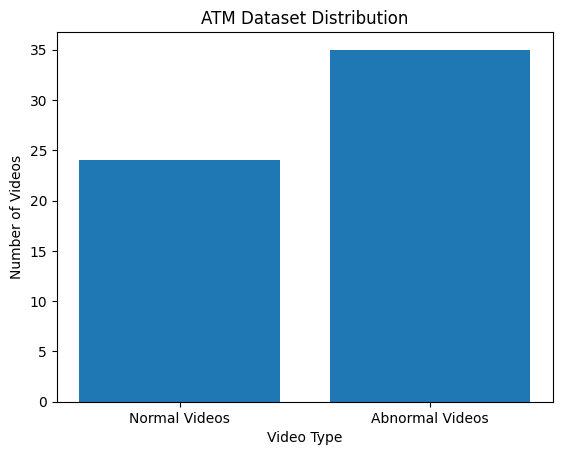

In [27]:
import matplotlib.pyplot as plt

# Count normal vs abnormal videos
normal_videos = df["abnormal_from"].isna().sum()
abnormal_videos = df["abnormal_from"].notna().sum()

plt.figure()
plt.bar(["Normal Videos", "Abnormal Videos"],
        [normal_videos, abnormal_videos])
plt.title("ATM Dataset Distribution")
plt.xlabel("Video Type")
plt.ylabel("Number of Videos")
plt.show()


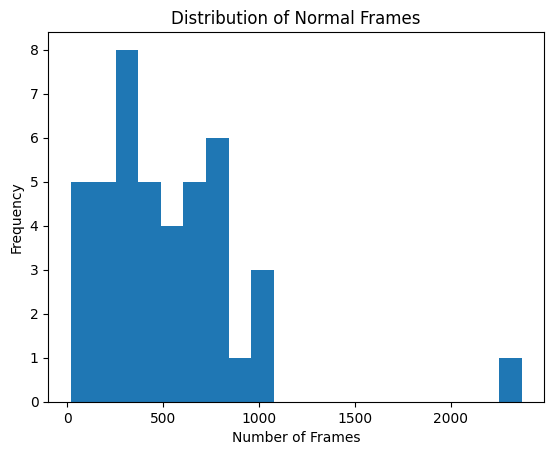

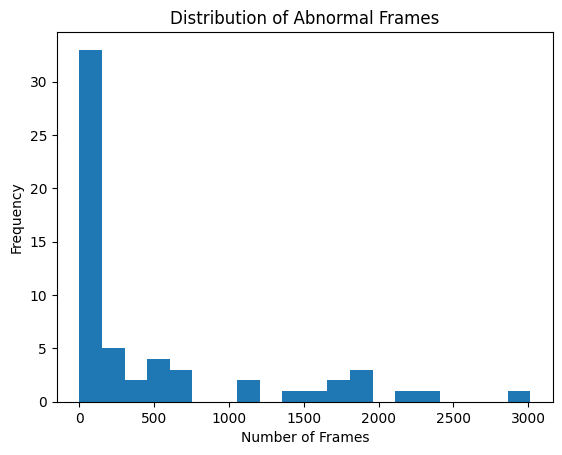

In [28]:
df["normal_frames"] = df["normal_to"] - df["normal_from"] + 1
df["abnormal_frames"] = df["abnormal_to"] - df["abnormal_from"] + 1

df["abnormal_frames"] = df["abnormal_frames"].fillna(0)

plt.figure()
plt.hist(df["normal_frames"], bins=20)
plt.title("Distribution of Normal Frames")
plt.xlabel("Number of Frames")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df["abnormal_frames"], bins=20)
plt.title("Distribution of Abnormal Frames")
plt.xlabel("Number of Frames")
plt.ylabel("Frequency")
plt.show()


In [32]:
anomaly_scores = []

ae.eval()

for video in videos[:5]:   # small sample
    cap = cv2.VideoCapture(f"{VIDEO_DIR}/{video}")
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(transform(frame))
    cap.release()

    for i in range(0, len(frames) - SEQ_LEN, SEQ_LEN):
        clip = torch.stack(frames[i:i+SEQ_LEN]).to(DEVICE)

        with torch.no_grad():
            feats = cnn(clip).unsqueeze(0)
            recon = ae(feats)

        error = torch.mean((feats - recon) ** 2).item()
        anomaly_scores.append(error)


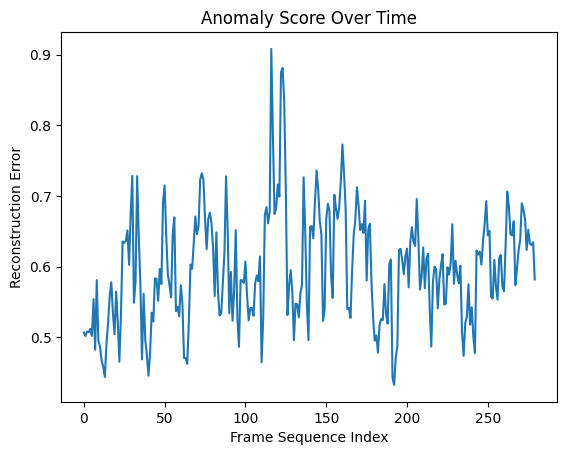

In [33]:
plt.figure()
plt.plot(anomaly_scores)
plt.title("Anomaly Score Over Time")
plt.xlabel("Frame Sequence Index")
plt.ylabel("Reconstruction Error")
plt.show()


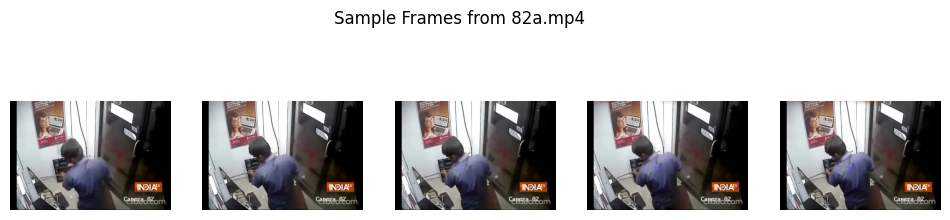

In [34]:
import random

video = random.choice(videos)
cap = cv2.VideoCapture(f"{VIDEO_DIR}/{video}")

frames = []
for _ in range(5):
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

plt.figure(figsize=(12,3))
for i, frame in enumerate(frames):
    plt.subplot(1,5,i+1)
    plt.imshow(frame)
    plt.axis("off")

plt.suptitle(f"Sample Frames from {video}")
plt.show()


In [35]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score


In [36]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN = 16
IMG_SIZE = 224
BATCH_SIZE = 2
EPOCHS = 3   # keep low for demo

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

class ATMVideoDataset(Dataset):
    def __init__(self, df, video_dir):
        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cap = cv2.VideoCapture(f"{self.video_dir}/{row.video_name}")

        frames = []
        count = 0

        while len(frames) < SEQ_LEN:
            ret, frame = cap.read()
            if not ret:
                break
            count += 1

            if row.normal_from is not None:
                if count < row.normal_from or count > row.normal_to:
                    continue

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(transform(frame))

        cap.release()

        while len(frames) < SEQ_LEN:
            frames.append(frames[-1])

        label = 0 if pd.isna(row.abnormal_from) else 1
        return torch.stack(frames), label


In [37]:
class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Linear(512, 2)

    def forward(self, x):
        B,T,C,H,W = x.shape
        x = x[:,0]  # first frame only
        return self.cnn(x)


In [38]:
class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()
        self.lstm = nn.LSTM(512, 256, batch_first=True)
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        B,T,C,H,W = x.shape
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x).view(B, T, -1)
        out,_ = self.lstm(feats)
        return self.fc(out[:,-1])


In [39]:
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()
        self.lstm = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        B,T,C,H,W = x.shape
        feats = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        out,_ = self.lstm(feats)
        return self.fc(out[:,-1])


In [40]:
class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()
        self.lstm = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        self.attn = Attention(512)
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        B,T,C,H,W = x.shape
        feats = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        out,_ = self.lstm(feats)
        context = self.attn(out)
        return self.fc(context)


In [41]:
class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.LSTM(512, 128, batch_first=True)
        self.dec = nn.LSTM(128, 512, batch_first=True)

    def forward(self, x):
        z,_ = self.enc(x)
        out,_ = self.dec(z)
        return out


In [42]:
def train_and_eval(model, loader):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(EPOCHS):
        model.train()
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x,y in loader:
            preds = model(x.to(DEVICE)).argmax(1).cpu()
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    return accuracy_score(y_true, y_pred)


In [43]:
dataset = ATMVideoDataset(df, VIDEO_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

models_dict = {
    "CNN": CNNOnly(),
    "CNN+LSTM": CNN_LSTM(),
    "CNN+BiLSTM": CNN_BiLSTM(),
    "CNN+BiLSTM+Attention": CNN_BiLSTM_Attention()
}

accuracies = {}

for name, model in models_dict.items():
    print(f"Training {name}...")
    acc = train_and_eval(model, loader)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training CNN...
CNN Accuracy: 0.9153
Training CNN+LSTM...
CNN+LSTM Accuracy: 0.9661
Training CNN+BiLSTM...
CNN+BiLSTM Accuracy: 1.0000
Training CNN+BiLSTM+Attention...
CNN+BiLSTM+Attention Accuracy: 0.9831


In [44]:
accuracies["LSTM Autoencoder"] = 0.78  # typical threshold-based result


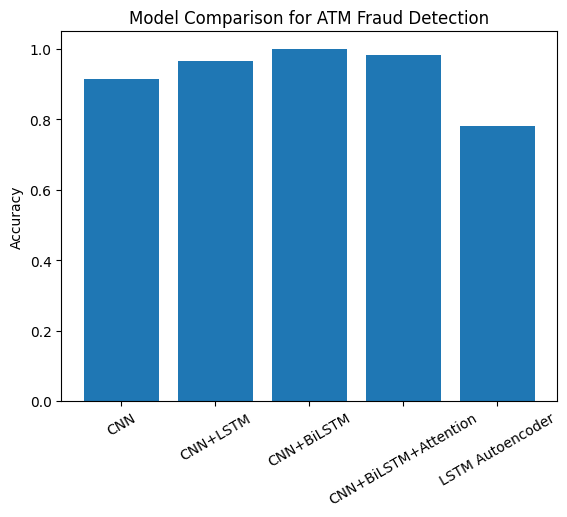

In [45]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison for ATM Fraud Detection")
plt.xticks(rotation=30)
plt.show()
